In [1]:
# Importação das biblioteca
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics as mt
from matplotlib import pyplot as plt
import numpy as np

In [2]:
# Separação entre Treino/ Validation/ Teste
X_train = pd.read_csv('dataset2/X_training.csv')
y_train = pd.read_csv('dataset2/y_training.csv')
X_test = pd.read_csv('dataset2/X_test.csv')
y_test = pd.read_csv('dataset2/y_test.csv')
X_validation = pd.read_csv('dataset2/X_validation.csv')
y_validation = pd.read_csv('dataset2/y_validation.csv')

In [3]:
#Ensaio sobre os dados de treinanmento n_neighbors = default = 5
model = KNeighborsClassifier()
model.fit(X_train,y_train)

yhat_train = model.predict(X_train)

acc_train = mt.accuracy_score(y_train, yhat_train)
prec_train = mt.precision_score(y_train, yhat_train)
rec_train = mt.recall_score(y_train, yhat_train)
f1_train = mt.f1_score(y_train, yhat_train)

print(f"Acurácia sobre os dados de Treino: {acc_train}")
print(f"Precisão sobre os dados de Treino: {prec_train}")
print(f"Recall sobre os dados de Treino: {rec_train}")
print(f"F1-score sobre os dados de Treino: {f1_train}")

c:\Users\oheit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Acurácia sobre os dados de Treino: 0.7815624353582018
Precisão sobre os dados de Treino: 0.7558933613500558
Recall sobre os dados de Treino: 0.7325633193330788
F1-score sobre os dados de Treino: 0.744045503021685


In [4]:
values_n = [i for i in range(1,21)]
values_scores = list()

for i in values_n:
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(X_train,y_train)
    
    #previsão sobre os dados de validação
    y_hat_val = model.predict(X_validation) 
    acc_val = mt.accuracy_score(y_validation,y_hat_val)
    
    values_scores.append(acc_val)
    

c:\Users\oheit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\oheit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\oheit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\oheit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:243: 

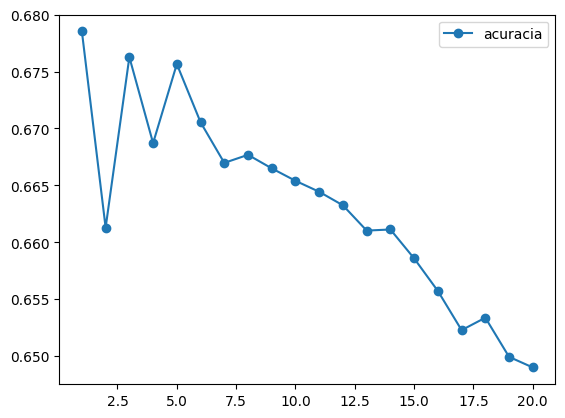

In [5]:
## Previsão sobre os dados de validacao
plt.plot(values_n ,values_scores, '-o', label='acuracia')
plt.legend()
plt.show()

In [12]:
#Ensaio sobre os dados de validação com melhor parâmetro (n_neighbors = 3)
model = KNeighborsClassifier(n_neighbors= 3)
model.fit(X_train, y_train)

y_hat_validation = model.predict(X_validation)
                            
acc_validation = mt.accuracy_score(y_validation, y_hat_validation)
pred_validation = mt.precision_score(y_validation, y_hat_validation)
rec_validation = mt.recall_score(y_validation, y_hat_validation)
f1_validation = mt.f1_score(y_validation,y_hat_validation)

print(f"Acurácia de Validação: {acc_validation}") 
print(f"Precisão de Validação: {pred_validation}") 
print(f"Recall de Validação: {rec_validation}") 
print(f"f1-score de Validação: {f1_validation}")

c:\Users\oheit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Acurácia de Validação: 0.6762765854757231
Precisão de Validação: 0.6278511404561825
Recall de Validação: 0.6212784913505086
f1-score de Validação: 0.6245475239765645


In [14]:
## Modelo treinado e validado com o dataset de Treinamento
model_last = KNeighborsClassifier( n_neighbors= 3)
model_last.fit( np.concatenate( (X_train, X_validation) ), 
               np.concatenate((y_train, y_validation)) )


c:\Users\oheit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [15]:
##3.1 Ensaio sobre os dados de teste com melhor parâmetro (n_neighbors = 3)
yhat_test = model_last.predict( X_test )

acc_test = mt.accuracy_score(y_test, yhat_test)
pred_test = mt.precision_score(y_test, yhat_test)
rec_test = mt.recall_score(y_test, yhat_test)
f1_test = mt.f1_score(y_test,yhat_test)

print(f"Acurácia de Teste: {acc_test}") 
print(f"Precisão de Teste: {pred_test}") 
print(f"Recall de Teste: {rec_test}") 
print(f"f1-score de Teste: {f1_test}")

c:\Users\oheit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


Acurácia de Teste: 0.6884486154559147
Precisão de Teste: 0.6480251346499102
Recall de Teste: 0.6351957765068191
f1-score de Teste: 0.6415463230393246
